# Week 1 Machine Learning Internship
## Task 1 - Load and Explore the Dataset

In this task, we will:
- Load the Titanic dataset.
- Display the first five rows.
- Check the dataset dimensions.
- View data types.
- Generate statistical summaries.
- Identify missing values.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the Titanic dataset
df = pd.read_csv("train.csv")

# Display the first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Display the shape of the dataset
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(891, 12)


In [3]:
# Display column names
print("Column Names:")
print(df.columns)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [4]:
# Display data types
print("Data Types:")
print(df.dtypes)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [5]:
# Display statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Task 2 - Handle Missing Values

Real-world datasets often contain missing values.

For this dataset:

- Age is numerical, so we fill missing values using the median.
- Embarked is categorical, so we fill missing values using the mode.
- Cabin has too many missing values, so we remove the entire column.

In [8]:
# Fill missing values in Age with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing values in Embarked using the mode (most frequent value)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop the Cabin column because it has too many missing values
df.drop("Cabin", axis=1, inplace=True)

# Check that all missing values have been handled
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Task 3 - Encode Categorical Variables

Machine Learning models cannot work with text values.

We use Label Encoding because:

- It converts text into numbers.
- It is simple and suitable for this dataset.

In [9]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Create encoder object
label_encoder = LabelEncoder()

# Encode Sex column
df["Sex"] = label_encoder.fit_transform(df["Sex"])

# Encode Embarked column
df["Embarked"] = label_encoder.fit_transform(df["Embarked"])

# Display first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


# Task 4 - Data Visualization

In this task we visualize the dataset using:

- Histograms
- Bar Chart
- Correlation Heatmap

Visualizations help us understand the distribution and relationships between variables.

In [10]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

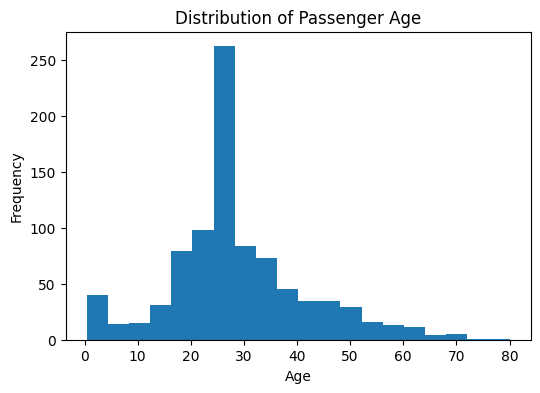

In [11]:
# Histogram for Age

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

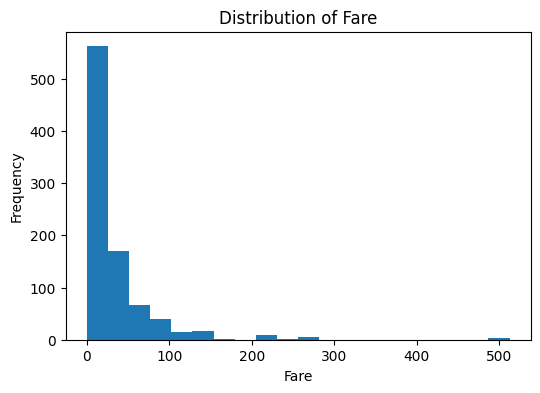

In [12]:
# Histogram for Fare

plt.figure(figsize=(6,4))
plt.hist(df["Fare"], bins=20)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

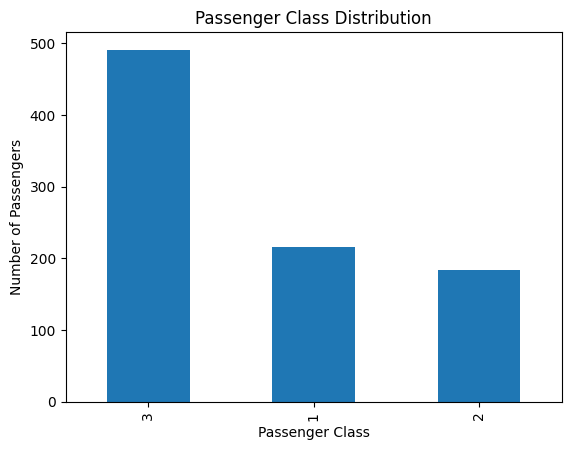

In [13]:
# Bar chart for Passenger Class

df["Pclass"].value_counts().plot(kind="bar")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

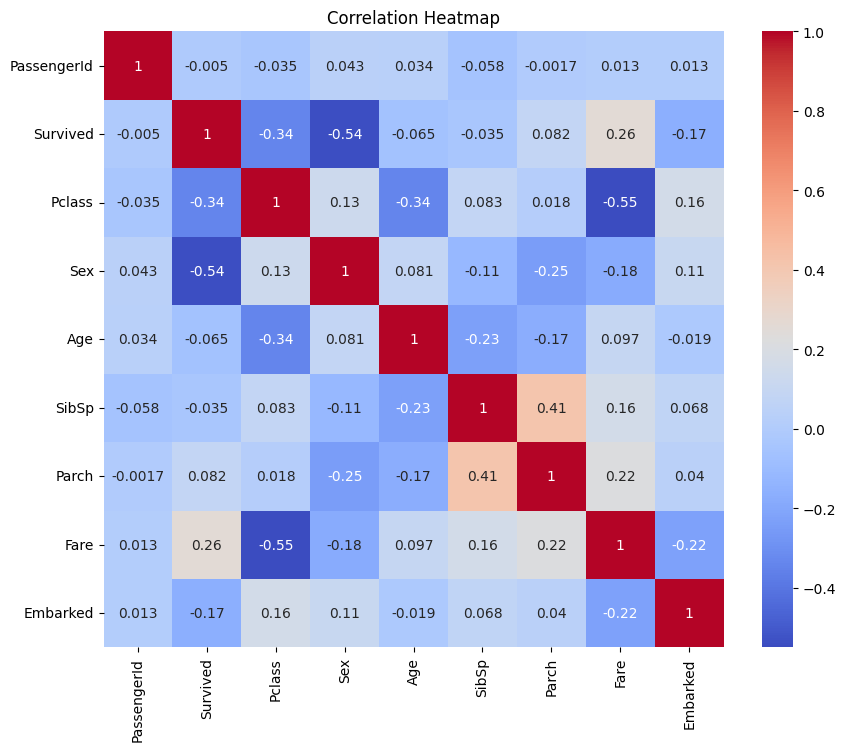

In [15]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Task 5 – Observations

## Observation 1
Female passengers had a higher survival rate than male passengers, indicating that gender was one of the most important factors affecting survival.

---

## Observation 2
Passengers traveling in First Class (Pclass = 1) were more likely to survive than passengers in Second and Third Class, showing that passenger class had a strong influence on survival.

---

## Observation 3
Passengers who paid higher fares generally had better survival rates, suggesting that the **Fare** feature is positively related to survival.

---

## Observation 4
The **Age** feature showed only a weak relationship with survival. It had some influence but was less important than **Sex**, **Pclass**, and **Fare**.

---

## Observation 5
The **Cabin** column contained a large number of missing values and was removed during preprocessing. The **Name** and **Ticket** columns also appeared less relevant for predicting survival compared to other features.

---

# Conclusion

### Most Important Features
- Sex
- Pclass
- Fare

### Less Relevant Features
- Cabin
- Name
- Ticket